- ### In ada_boost the best results are given by thr random forest and the and there is max one split given
- In Ada_boost there is only +1 and -1

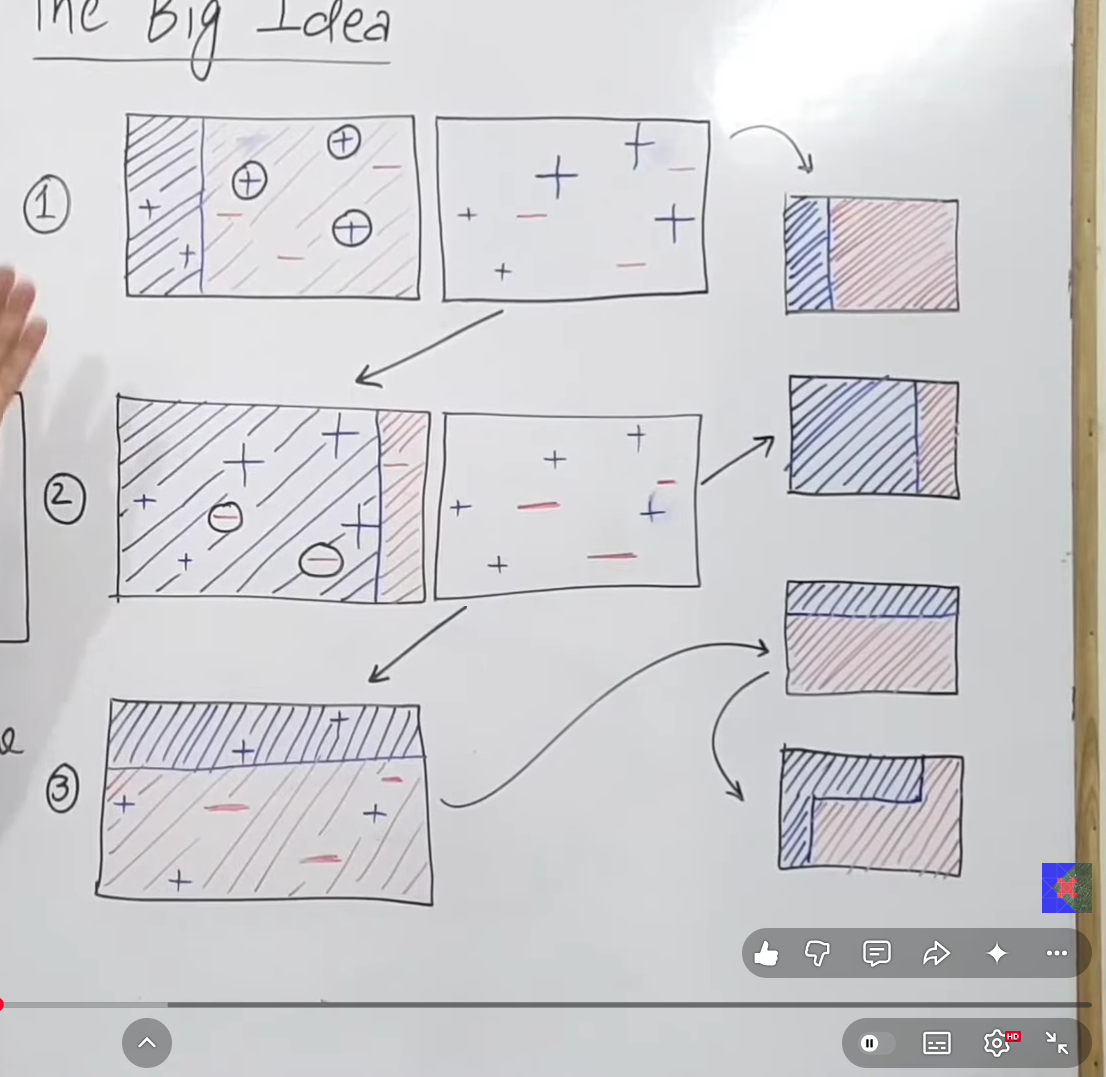

## It uses the state wise additive method that is the final result is calculated by combining multiple week learners

_  After one learner completes the leraning after that we tell the model to increase the focus on wrong point that these were the unclassifed point focus on them 

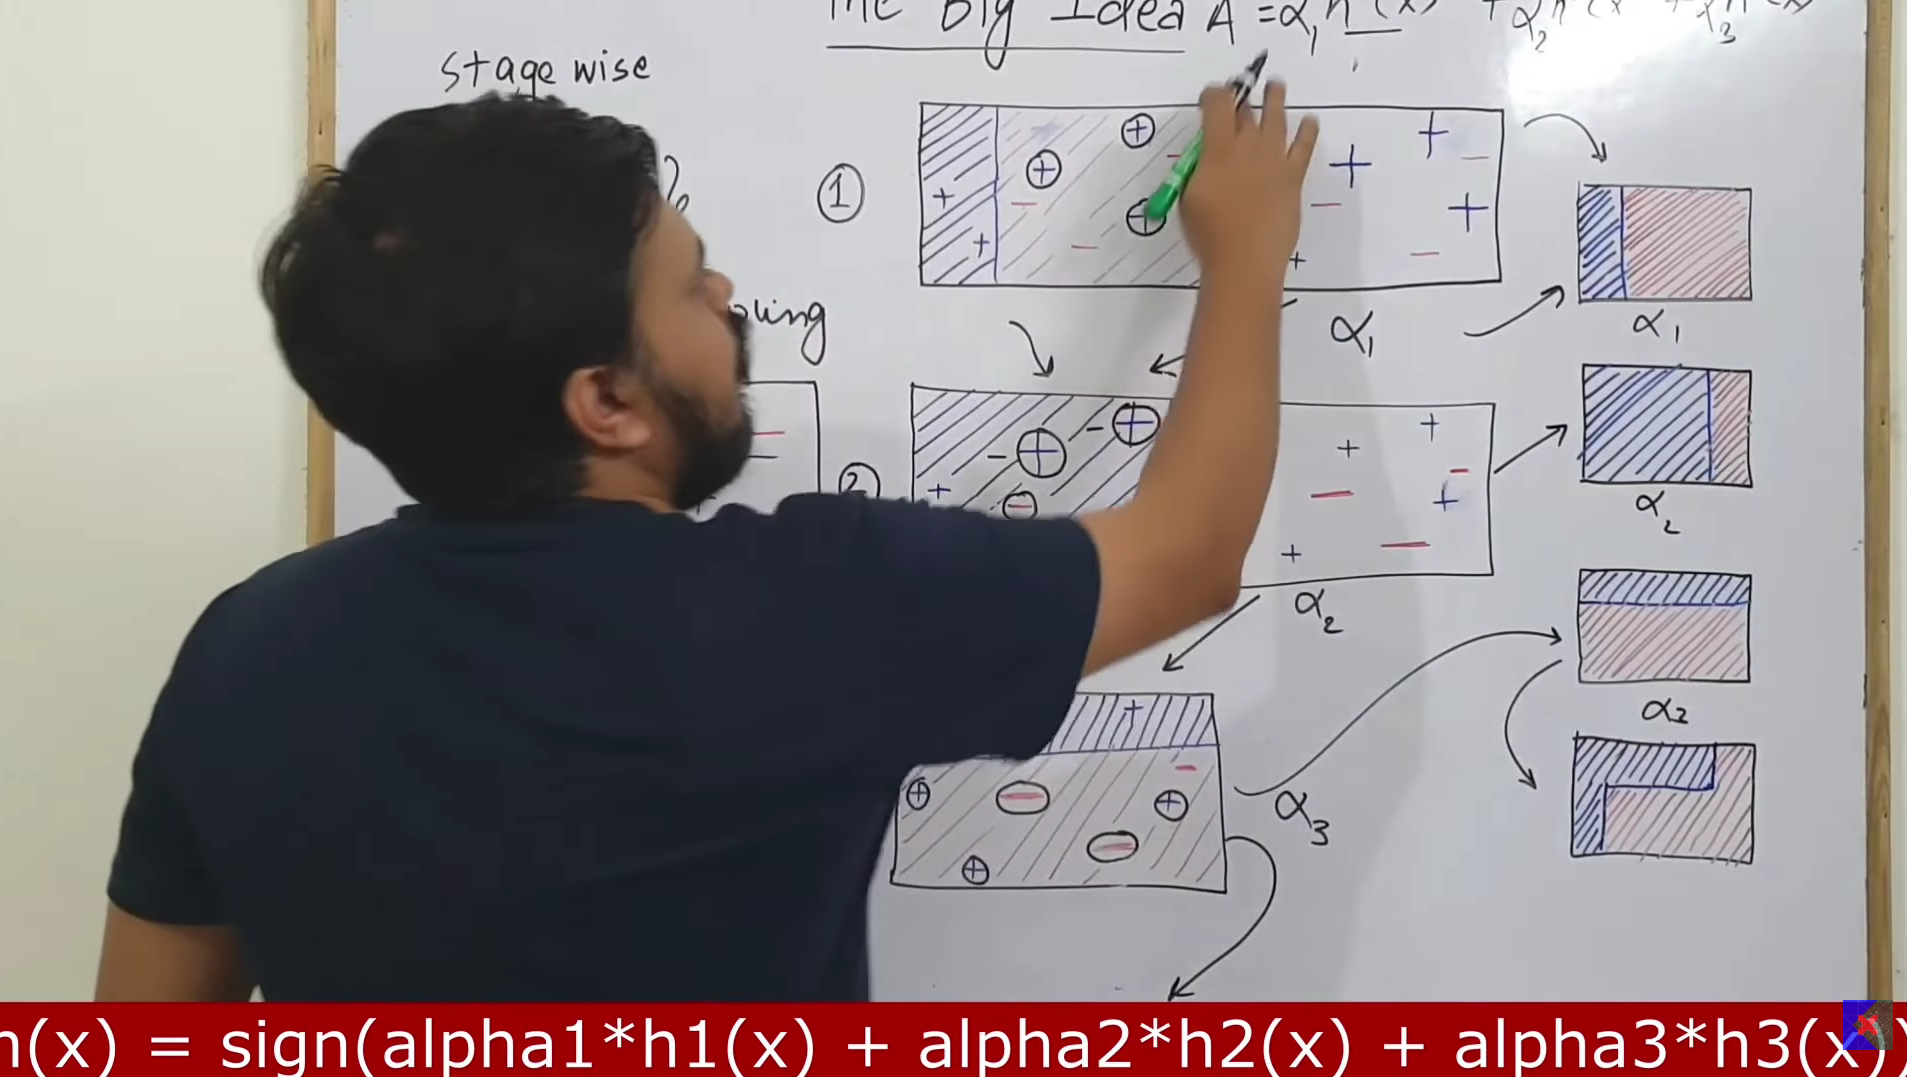

# AdaBoost - Step by Step

### Initial Dataset

- Number of samples: **n = 5**
- Initial weight for every sample:

$
w_i = \frac{1}{5} = 0.2
$

| Sample | X₁ | X₂ | y | Weight |
|--------|----|----|---|--------|
| 1 | 3 | 7 | 1 | 0.2 |
| 2 | 2 | 9 | 0 | 0.2 |
| 3 | 1 | 8 | 1 | 0.2 |
| 4 | 6 | 8 | 0 | 0.2 |
| 5 | 3 | 7 | 0 | 0.2 |

---

## Stage 1

### Weak Learner (M₁)

Possible decision stumps:

```
X₁ > 5
```

or

```
X₂ < 10
```

$$
\alpha_1 \text{ which is the say of the model1 while final prediction}
$$

- ### It will depend on the error rate of this model


# Stage 1: Calculating the Importance of a Weak Learner (α)

Once the first weak learner (Decision Stump) is trained, AdaBoost measures **how good that learner is**.

Instead of treating every weak learner equally, AdaBoost assigns an **importance score**, denoted by **α (Alpha)**.

The importance is calculated as

$$
\alpha=\frac{1}{2}\ln\left(\frac{1-\text{Error}}{\text{Error}}\right)
$$

where

- **Error** = Weighted classification error of the weak learner.
- **α (Alpha)** = Confidence (importance) assigned to that weak learner.

---

# Why do we need α?

Suppose we train three decision stumps.

| Weak Learner | Accuracy | Error |
|--------------|----------|-------|
| Model A | 50% | 0.50 |
| Model B | 75% | 0.25 |
| Model C | 100% | 0.00 |

Should every model get the same vote?

**No.**

Clearly,

- Model C is the best.
- Model B is reasonably good.
- Model A is no better than random guessing.

Therefore, AdaBoost gives **larger weight** to better models and **smaller weight** to weaker models.

The value **α** tells us **how much we should trust each weak learner** during the final prediction.

---

# Understanding the Formula

The formula is

$$
\alpha=\frac12\ln\left(\frac{1-\text{Error}}{\text{Error}}\right)
$$

Notice that α depends only on the classification error.

As the error decreases, α increases.

As the error increases, α decreases.

---

# Case 1 : Perfect Classifier

Suppose

$$
\text{Error}=0
$$

Then

$$
\alpha
=
\frac12
\ln
\left(
\frac{1}{0}
\right)
\rightarrow
+\infty
$$

A perfect classifier receives an extremely large positive weight.

This means AdaBoost trusts this model almost completely.

---

# Case 2 : Random Guessing

Suppose

$$
\text{Error}=0.5
$$

Then

$$
\alpha
=
\frac12
\ln
\left(
\frac{0.5}{0.5}
\right)
=
\frac12\ln(1)
=
0
$$

An α of zero means the learner contributes **nothing**.

Since it performs no better than random guessing, AdaBoost ignores it.

---

# Case 3 : Worse Than Random

Suppose

$$
\text{Error}=0.8
$$

Then

$$
\alpha
=
\frac12
\ln
\left(
\frac{0.2}{0.8}
\right)
$$

Since

$$
\ln\left(\frac{0.2}{0.8}\right)<0
$$

we obtain

$$
\alpha<0
$$

A negative α indicates that the learner is worse than random guessing.

Instead of trusting such a model, AdaBoost would rather flip its predictions.

---

# Graph of Error vs α

```
                α (Importance)
                   ↑
                   │
         Large     │
                   │
                   │
                   │
                   │
                   │\
                   │ \
                   │  \
                   │   \
                   │    \
───────────────────┼─────\────────────────────→ Error
                   0     0.5                 1

               α > 0     α = 0         α < 0
```

---

# Understanding the Graph

### Error = 0

- Perfect classifier
- Maximum confidence
- Very large α

---

### Error < 0.5

- Better than random guessing
- Positive α
- AdaBoost trusts the model.

---

### Error = 0.5

- Random guessing
- α = 0
- Model has no contribution.

---

### Error > 0.5

- Worse than random guessing
- Negative α
- The learner hurts the ensemble.

---

# Why Do We Use the Logarithm?

Instead of assigning weights linearly, AdaBoost uses the logarithm because it provides a smooth relationship between error and importance.

It satisfies all the desired properties:

- Very small error → Very large positive α
- Moderate error → Moderate α
- Error = 0.5 → α = 0
- Error > 0.5 → Negative α

This makes better classifiers dominate the final prediction while weaker classifiers contribute much less.

---

# Intuition Behind α

Think of α as a **confidence score**.

- Large α → "I trust this weak learner a lot."
- Small α → "I trust it only a little."
- α = 0 → "Ignore this learner."
- Negative α → "This learner is misleading."

Thus, α determines **how much voting power** each weak learner receives.

---

# Final Prediction in AdaBoost

Suppose we have three weak learners.

| Weak Learner | Prediction | α |
|--------------|------------|----|
| M₁ | +1 | 1.5 |
| M₂ | +1 | 0.8 |
| M₃ | -1 | 0.2 |

AdaBoost computes

$$
\text{Final Prediction}
=
\operatorname{sign}
\left(
1.5(+1)
+
0.8(+1)
+
0.2(-1)
\right)
$$

which becomes

$$
=
\operatorname{sign}(2.1)
=
+1
$$

Notice that the strongest learner contributes the most because it has the highest α.

---

# Key Takeaways

- AdaBoost does **not** treat all weak learners equally.
- Each weak learner receives an importance score

$$
\boxed{\alpha=\frac12\ln\left(\frac{1-\text{Error}}{\text{Error}}\right)}
$$
- Error is the sum of the  weights that are misclassified
- Smaller error leads to larger α.
- Error equal to **0.5** gives α equal to **0**.
- Error greater than **0.5** produces a negative α.
- During the final prediction, learners with larger α have a much greater influence than learners with smaller α.

#  Now whaat we have to do is that we will have to increse the weights of the incorrectly classified points and decrease the weights of the points that are correctly classified

# Stage 2: Updating Sample Weights

After calculating the importance of the weak learner

$$
\alpha=\frac12\ln\left(\frac{1-\text{Error}}{\text{Error}}\right)
$$

AdaBoost updates the weight of every training sample.

The main idea is simple:

- Increase the weights of the samples that were **misclassified**.
- Decrease the weights of the samples that were **classified correctly**.

This forces the next weak learner to focus more on the difficult examples.

---

# Why Update the Weights?

Suppose we have 100 training samples.

The first decision stump correctly classifies 90 samples but makes mistakes on 10 samples.

If we train the next stump using the same weights, it may make the **same mistakes again**.

Instead, AdaBoost increases the importance of those 10 misclassified samples so that the next weak learner pays more attention to them.

---

# Weight Update Rule

## For Misclassified Samples

If a sample is classified incorrectly,

$$
\boxed{
w_{\text{new}}
=
w_{\text{old}}
\times
e^{\alpha}
}
$$

Since

$$
e^{\alpha}>1
$$

the weight increases.

This means the sample becomes more important for the next weak learner.

---

## For Correctly Classified Samples

If a sample is classified correctly,

$$
\boxed{
w_{\text{new}}
=
w_{\text{old}}
\times
e^{-\alpha}
}
$$

Since

$$
e^{-\alpha}<1
$$

the weight decreases.

The next weak learner spends less effort on these already-correct samples.

---

# Example

Initially every sample has equal weight.

Suppose

$$
w=0.2
$$

and

$$
\alpha=0.2
$$

---

## Misclassified Sample

Using

$$
w_{\text{new}}
=
w_{\text{old}}
\times
e^{\alpha}
$$

we obtain

$$
w_{\text{new}}
=
0.2\times e^{0.2}
$$

Since

$$
e^{0.2}\approx1.221
$$

therefore

$$
w_{\text{new}}
=
0.2\times1.221
\approx0.244
$$

The weight increases from

$$
0.20
\rightarrow
0.244
$$

---

## Correctly Classified Sample

Using

$$
w_{\text{new}}
=
w_{\text{old}}
\times
e^{-\alpha}
$$

we obtain

$$
w_{\text{new}}
=
0.2\times e^{-0.2}
$$

Since

$$
e^{-0.2}\approx0.819
$$

therefore

$$
w_{\text{new}}
=
0.2\times0.819
\approx0.164
$$

The weight decreases from

$$
0.20
\rightarrow
0.164
$$

---

# Before Normalization

| Sample Status | Old Weight | Formula | New Weight |
|---------------|-----------:|---------|-----------:|
| Misclassified | 0.20 | $$0.2e^{0.2}$$ | 0.244 |
| Correct | 0.20 | $$0.2e^{-0.2}$$ | 0.164 |

Notice that the weights no longer sum to 1.

---

# Why Normalize?

After updating the weights,

$$
\sum_i w_i \neq 1
$$

However, AdaBoost treats these weights as a probability distribution.

Therefore we normalize them using

$$
\boxed{
w_i
=
\frac{w_i}
{\sum_j w_j}
}
$$

After normalization,

$$
\sum_i w_i=1
$$

This keeps the weights valid probabilities while preserving their relative importance.

---

# Intuition

Think of a teacher checking exam papers.

- Students who answered correctly do not need much attention.
- Students who made mistakes require extra practice.

AdaBoost follows exactly the same strategy.

After each weak learner,

- difficult samples receive **higher weights**,
- easy samples receive **lower weights**.

The next weak learner is therefore forced to concentrate on the mistakes made by the previous learner.

---

# Visual Intuition

```
Initial Weights

Sample 1   █████
Sample 2   █████
Sample 3   █████
Sample 4   █████
Sample 5   █████


After First Weak Learner

Correct Sample        ████
Correct Sample        ████
Misclassified         ███████
Correct Sample        ████
Misclassified         ███████
```

The difficult (misclassified) samples become heavier, while the easy samples become lighter.

---

# Key Takeaways

- Misclassified samples receive **higher weights**

$$
w_{\text{new}}
=
w_{\text{old}}e^{\alpha}
$$

- Correctly classified samples receive **lower weights**

$$
w_{\text{new}}
=
w_{\text{old}}e^{-\alpha}
$$

- The updated weights are then **normalized** so that

$$
\sum_i w_i=1
$$

- This ensures that every new weak learner focuses increasingly on the examples that previous learners found difficult.

# Final Step of increasing the importance of incorrectly classified points

# Stage 3: Creating the New Training Dataset

After updating and normalizing the weights, AdaBoost creates a **new training dataset**.

Instead of selecting every sample equally, samples are selected **according to their weights**.

Samples with larger weights have a higher probability of being selected multiple times.

Samples with smaller weights may not be selected at all.

---

# Updated Weights

Suppose after normalization we obtain the following weights.

| Sample | $X_1$ | $X_2$ | $Y$ | Weight |
|--------:|------:|------:|----:|-------:|
| 1 | 3 | 7 | 1 | 0.166 |
| 2 | 2 | 9 | 0 | 0.250 |
| 3 | 1 | 4 | 1 | 0.250 |
| 4 | 9 | 8 | 0 | 0.166 |
| 5 | 3 | 7 | 0 | 0.166 |

Notice that

$$
0.166+0.25+0.25+0.166+0.166=1
$$

Since the weights sum to 1, they can be interpreted as probabilities.

---

# Constructing Probability Ranges

To perform weighted sampling, each sample is assigned an interval on the number line from **0 to 1**.

| Sample | Weight | Probability Range |
|---------|--------|------------------|
| 1 | 0.166 | $0.000-0.166$ |
| 2 | 0.250 | $0.166-0.416$ |
| 3 | 0.250 | $0.416-0.666$ |
| 4 | 0.166 | $0.666-0.832$ |
| 5 | 0.166 | $0.832-1.000$ |

Graphically,

```

0 --------------------------------------------------------- 1

|----S1----|--------S2--------|--------S3--------|----S4----|----S5----|

0 0.166 0.416 0.666 0.832 1.0

```

The larger the interval, the greater the chance of selecting that sample.

---

# Generate Random Numbers

Now generate random numbers between

$$
0 \le r \le 1
$$

Suppose we generate

$$
0.13,\;
0.43,\;
0.62,\;
0.50,\;
0.80
$$

---

# Select Samples

Each random number belongs to one of the intervals.

### Random Number 0.13

$$
0.13\in[0,0.166]
$$

Select **Sample 1**.

---

### Random Number 0.43

$$
0.43\in[0.416,0.666]
$$

Select **Sample 3**.

---

### Random Number 0.62

$$
0.62\in[0.416,0.666]
$$

Select **Sample 3** again.

---

### Random Number 0.50

$$
0.50\in[0.416,0.666]
$$

Select **Sample 3** once more.

---

### Random Number 0.80

$$
0.80\in[0.666,0.832]
$$

Select **Sample 4**.

---

# New Training Dataset

The sampled indices become

$$
[1,\;3,\;3,\;3,\;4]
$$

The new dataset is

| Sample | $X_1$ | $X_2$ | $Y$ |
|---------|------:|------:|----:|
| 1 | 3 | 7 | 1 |
| 3 | 1 | 4 | 1 |
| 3 | 1 | 4 | 1 |
| 3 | 1 | 4 | 1 |
| 4 | 9 | 8 | 0 |

Notice that

- Sample 3 appears **three times** because it has a higher weight.
- Samples with lower weights appear fewer times.
- Some samples may disappear completely.

---

# Why Do We Do This?

The previous weak learner struggled to classify certain samples correctly.

These difficult samples received higher weights.

During weighted sampling,

- difficult samples appear more frequently,
- easy samples appear less frequently.

As a result, the next weak learner naturally focuses on correcting the mistakes made by the previous learner.

---



# Since incorrecly has more weight so it willl have more range and there is more chance that it will be selected